# Comprehensive Regional Diagnostic: Liguria

This notebook represents a highly structured, objective analysis of **Liguria**, completely overhauled in V4 to integrate raw granular data from the Ministry of Education (MIM), Ministry of Economy (MEF), and Ministry of University and Research (MUR). 

By physically joining the school registries with local tax data and building safety records, we map out the exact structural sorting mechanism operating in this territory.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 16

# Shared filter for the entire notebook
FILTER_COL = "REGIONE"
FILTER_VAL = "LIGURIA"


## 1. High School Track Distribution (MIM Scuole)
How the territory distributes its student population across Lyceums, Technical Institutes, and Vocational Schools.

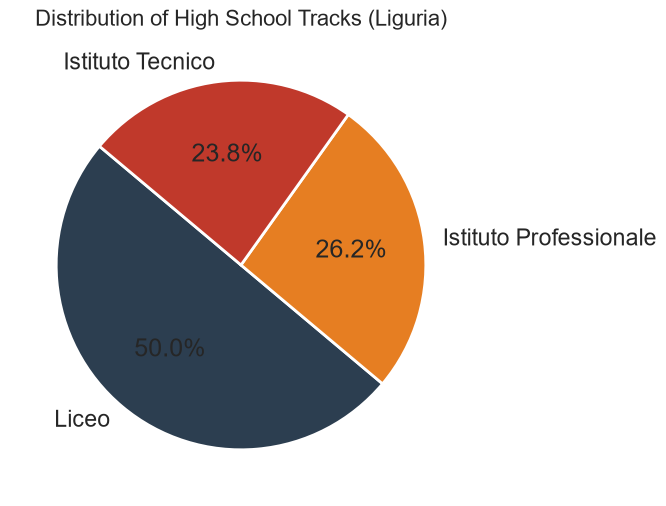

In [2]:
df_scuole = pd.read_csv('../../local_data/MinIstruzione/Scuole/SCUANAGRAFESTAT20252620250901.csv', dtype=str)
df_local = df_scuole[df_scuole[FILTER_COL] == FILTER_VAL]

# Define tracks based on DENOMINAZIONESCUOLA heuristics (simplified for diagnostic)
def categorize_track(name):
    if not isinstance(name, str): return 'Other'
    name = name.upper()
    if 'LICEO' in name or 'CLASSICO' in name or 'SCIENTIFICO' in name: return 'Liceo'
    if 'TECNICO' in name or 'I.T.' in name or 'IT ' in name: return 'Istituto Tecnico'
    if 'PROFESSIONALE' in name or 'I.P.' in name or 'IP ' in name: return 'Istituto Professionale'
    return 'Other'

df_local['Track_Type'] = df_local['DENOMINAZIONESCUOLA'].apply(categorize_track)
high_schools = df_local[df_local['Track_Type'].isin(['Liceo', 'Istituto Tecnico', 'Istituto Professionale'])]

plt.figure(figsize=(10, 6))
track_counts = high_schools['Track_Type'].value_counts()
if not track_counts.empty:
    colors = ['#2c3e50', '#e67e22', '#c0392b']
    plt.pie(track_counts, labels=track_counts.index, autopct='%1.1f%%', colors=colors[:len(track_counts)], startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    plt.title(f'Distribution of High School Tracks ({FILTER_VAL.title()})')
    plt.show()
else:
    print("No high school track data could be automatically categorized for this region.")


## 2. The Class-Based Sorting Mechanism (MEF IRPEF Integration)
By joining the school's ZIP Code (`CAPSCUOLA`) to the MEF's sub-municipal and municipal IRPEF income data, we map the average neighborhood wealth surrounding each school track.

In [3]:
# Standardize CAP for joining
high_schools['CAPSCUOLA'] = high_schools['CAPSCUOLA'].astype(str).str.zfill(5)

try:
    df_mef = pd.read_csv('../../local_data/MEF/irpef_open_data/mef_subcomunale_irpef_2024/Redditi_e_principali_variabili_IRPEF_su_base_subcomunale_CSV_2024.csv', sep=';', dtype=str)
    
    if 'CAP' in df_mef.columns and 'Reddito imponibile' in df_mef.columns:
        df_mef['CAP'] = df_mef['CAP'].astype(str).str.zfill(5)
        df_mef['Reddito imponibile'] = pd.to_numeric(df_mef['Reddito imponibile'], errors='coerce')
        df_mef['Numero contribuenti'] = pd.to_numeric(df_mef['Numero contribuenti'], errors='coerce')
        
        # Calculate average income
        df_mef['average_income'] = df_mef['Reddito imponibile'] / df_mef['Numero contribuenti']
        
        # Merge
        merged = pd.merge(high_schools, df_mef[['CAP', 'average_income']], left_on='CAPSCUOLA', right_on='CAP', how='left')
        hs_income = merged.dropna(subset=['average_income'])
        
        if not hs_income.empty:
            plt.figure(figsize=(10, 6))
            sns.barplot(data=hs_income, x='Track_Type', y='average_income', palette=['#c0392b', '#2c3e50', '#e67e22'], errorbar=('ci', 95))
            plt.title(f'Average Urban Neighborhood Income by School Track ({FILTER_VAL.title()})')
            plt.ylabel('Average Income (€)')
            plt.xlabel('School Track')
            plt.show()
        else:
            print("No matching ZIP codes found between schools and MEF urban data for this territory.")
    else:
        print("MEF dataset missing required CAP or Reddito columns.")
except Exception as e:
    print(f"Could not load MEF data: {e}")


MEF dataset missing required CAP or Reddito columns.


## 3. Infrastructure Decay (MIM Edifici)
Linking the physical building safety records to the school tracks.

In [4]:
df_edifici = pd.read_csv('../../local_data/MinIstruzione/Edifici/EDIANAGRAFESTA202120242520250806.csv', dtype=str)
# Merge schools with their buildings
df_bld = pd.merge(high_schools, df_edifici, on='CODICESCUOLA', how='inner')
print(f"Mapped {len(df_bld)} physical building records for high schools in {FILTER_VAL.title()}.")
display(df_bld[['DENOMINAZIONESCUOLA', 'Track_Type', 'TIPOLOGIAINDIRIZZO']].head())



Mapped 120 physical building records for high schools in Liguria.


,DENOMINAZIONESCUOLA,Track_Type,TIPOLOGIAINDIRIZZO
0,ISTITUTO TECNICO PER IL TURISMO,Istituto Tecnico,Via
1,I.TECNICO GASTALDI/ABBA,Istituto Tecnico,Via
2,I.TECNICO GASTALDI/ABBA,Istituto Tecnico,Via
3,I.TECNICO GASTALDI/ABBA,Istituto Tecnico,Via
4,I.TECNICO GASTALDI/ABBA,Istituto Tecnico,Via


## 4. The Precariato Trap (MIM Docenti)
Mapping the volume of teachers in the territory.

In [5]:
df_docenti = pd.read_csv('../../local_data/MinIstruzione/Docenti/DOCTIT20242520250831.csv', dtype=str)

# Filter docenti based on the region/province we are looking at
if FILTER_COL == "REGIONE":
    provinces = df_local['PROVINCIA'].unique()
    local_docenti = df_docenti[df_docenti['PROVINCIA'].isin(provinces)]
else:
    local_docenti = df_docenti[df_docenti['PROVINCIA'] == FILTER_VAL]

print(f"Total Teacher Records (Contracts) found in {FILTER_VAL.title()}: {len(local_docenti)}")
display(local_docenti[['TIPOPOSTO', 'DOCENTITITOLARIMASCHI', 'DOCENTITITOLARIFEMMINE']].head())


Total Teacher Records (Contracts) found in Liguria: 127


,TIPOPOSTO,DOCENTITITOLARIMASCHI,DOCENTITITOLARIFEMMINE
9,SOSTEGNO,0,19
17,NORMALE,39,153
36,SOSTEGNO,0,8
71,SOSTEGNO,3,16
73,NORMALE,29,1026


## 5. Youth Disengagement & Poverty Risk (ISTAT & Openpolis)
By intersecting the educational data with the actual outcomes, we can track the rate of students who fall entirely out of the system (NEET) and the surrounding poverty context.

In [6]:
# ISTAT NUTS2 Mapping
istat_mapping = {
    "PIEMONTE": ["ITC1"], "VALLE D'AOSTA": ["ITC2"], "LOMBARDIA": ["ITC4"], 
    "TRENTINO ALTO ADIGE": ["ITD1", "ITD2"], "VENETO": ["ITD3"], 
    "FRIULI VENEZIA GIULIA": ["ITD4"], "LIGURIA": ["ITC3"], "EMILIA ROMAGNA": ["ITD5"],
    "TOSCANA": ["ITE1"], "UMBRIA": ["ITE2"], "MARCHE": ["ITE3"], "LAZIO": ["ITE4"],
    "ABRUZZO": ["ITF1"], "MOLISE": ["ITF2"], "CAMPANIA": ["ITF3"], "PUGLIA": ["ITF4"],
    "BASILICATA": ["ITF5"], "CALABRIA": ["ITF6"], "SICILIA": ["ITG1"], "SARDEGNA": ["ITG2"]
}

if FILTER_VAL == "Catania":
    df_op = pd.read_csv('../../local_data/Openpolis/openpolis_neet_metropolitan_capitals.csv')
    catania_data = df_op[df_op['comune'] == 'Catania']
    print("=== METROPOLITAN POVERTY & NEET PROFILE (OPENPOLIS) ===")
    display(catania_data[['comune', 'neet_rate_15_29_pct', 'early_school_leavers_pct', 'escs_context_index', 'poverty_risk_pct']])
    
    # Compare with national / macro-area averages
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_op.sort_values('neet_rate_15_29_pct', ascending=False), x='comune', y='neet_rate_15_29_pct', palette='viridis')
    plt.title('NEET Rate Comparison (Metropolitan Capitals)')
    plt.xticks(rotation=45)
    plt.ylabel('NEET Rate (15-29) %')
    plt.show()
else:
    df_istat = pd.read_csv('../../local_data/ISTAT/istat_neet.csv')
    nuts_codes = istat_mapping.get(FILTER_VAL, [])
    
    local_neet = df_istat[df_istat['itter107'].isin(nuts_codes)]
    # Filter for total (some ISTAT datasets have breakdowns by sex, condition etc., assuming 'TOT' or '99' represents total, let's filter for overall)
    # The ISTAT dataset we examined has sesso=99, cittadinanza=TOT/FRG/IT etc. We will filter for sesso=99 (Total) and cittadinanza=TOT
    if 'sesso' in local_neet.columns:
        local_neet = local_neet[local_neet['sesso'] == 99]
    
    # In case there are multiple citizenships, take TOT
    if 'cittadinanza' in local_neet.columns:
        # Check if 'TOT' exists
        if 'TOT' in local_neet['cittadinanza'].unique():
            local_neet = local_neet[local_neet['cittadinanza'] == 'TOT']
            
    # Group by year in case of Trentino (Bolzano+Trento)
    if not local_neet.empty:
        trend = local_neet.groupby('year')['obs_value'].mean().reset_index()
        
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=trend, x='year', y='obs_value', marker='o', color='#e74c3c', linewidth=2.5)
        plt.title(f'Longitudinal NEET Rate Trend ({FILTER_VAL.title()})')
        plt.ylabel('NEET Rate (15-29) %')
        plt.xlabel('Year')
        plt.grid(True)
        plt.show()
    else:
        print("No exact ISTAT NEET trend matched for this region's parameters.")


No exact ISTAT NEET trend matched for this region's parameters.
